[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ravi03071991/rl_hack/blob/master/train_hr_agent.ipynb)


# Reinforcement Learning for HR Onboarding: Teaching an LLM to Automate Enterprise Workflows

Built for the [OpenEnv Hackathon SF](https://cerebralvalley.ai/e/openenv-hackathon-sf/details) — **Statement 3.1: Professional Tasks** (Scaler AI Labs: Multi-App RL Environment for Enterprise Workflows)

We train an LLM to complete **HR onboarding and offboarding tasks** using **reinforcement learning (RL)**. The agent orchestrates across **6 enterprise apps** (HRIS, IT Asset Management, IAM, Email, Slack, Calendar) using 25 tools to complete multi-step workflows like:

- Creating employee records and initiating onboarding
- Assigning laptops, provisioning IT accounts, setting up access roles
- Sending welcome emails, scheduling orientation meetings
- Processing offboarding with asset reclaim and access revocation

**Requirements:** Google Colab (or any GPU with 16GB+ VRAM).

**Results:** GRPO training improves mean score from **0.370 → 0.617 (+67%)**, with complex task scores more than doubling (0.26 → 0.68). Generalizes to held-out test tasks.

## What is the HR Onboarding Environment?

This is an **OpenEnv-compatible RL environment** that simulates the HR department of a fictional company called **AcmeCorp**. It has:

- **200 employees** across 8 departments with a full org hierarchy (L1-L6 levels)
- **25 tools** the agent can call (HR, IT, access control, communication, policy)
- **77 tasks** across 4 difficulties (simple, medium, complex, edge case)
- **Rubric-based rewards** — each task has verifiable criteria (did you call the right tool? with the right params? in the right order?)

### Our Goal

The agent receives a task instruction (e.g., "Onboard Priya Sharma to Engineering as L2 Software Engineer") and must generate a **sequence of JSON tool calls** to complete it. Each tool call is one step. The agent has up to 15 steps per episode.

Unlike the 2048 tutorial where the model writes code, here the model **directly generates tool calls** — closer to how real enterprise agents work.

## Installation

We need:
1. **[Unsloth](https://github.com/unslothai/unsloth)** — Memory-efficient LLM training (~70% less VRAM)
2. **[TRL](https://github.com/huggingface/trl)** — GRPO trainer for RL
3. **Our HR environment** — Cloned from GitHub

In [ ]:
%%capture
import os, importlib.util

if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try:
        import numpy
        get_numpy = f"numpy=={numpy.__version__}"
    except:
        get_numpy = "numpy"
    !pip install \
        "torch>=2.8.0" "triton>=3.4.0" {get_numpy} torchvision bitsandbytes "transformers==4.56.2" trackio \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
elif importlib.util.find_spec("unsloth") is None:
    !pip install unsloth trackio

!pip install --upgrade --no-deps transformers==4.56.2 tokenizers trl==0.22.2 unsloth unsloth_zoo

Next, clone the HR environment and install it:

## Loading the Model

We load the model with memory optimizations to fit on a T4 GPU:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `max_seq_length` | 4096 | Longer context for multi-step tool calling |
| `load_in_4bit` | True | 4-bit quantization to reduce memory |
| `lora_rank` | 8 | LoRA adapter rank (balance of quality vs memory) |

In [ ]:
%%capture
!pip install openenv-core datasets pydantic python-dotenv wandb accelerate
!git clone https://github.com/ravi03071991/rl_hack.git 2>/dev/null || (cd rl_hack && git pull)

import sys
sys.path.insert(0, "rl_hack")
sys.path.insert(0, "rl_hack/server")

In [1]:
# Optional: wandb setup (uncomment and add your key)
import wandb
!wandb login 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
wandb.init(project="hr-agent-training")

wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jovyan/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.
wandb: Currently logged in as: ravi03071991 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 4096  # Longer context for multi-turn tool calling
lora_rank = 8
#     model_name="Qwen/Qwen2.5-7B-Instruct",
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-1B-Instruct",
    load_in_4bit=True,
    max_seq_length=max_seq_length,
)

/tmp/ipykernel_85278/4225710256.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/opt/conda/lib/python3.13/site-packages/triton/runtime/autotuner.py:101: DeprecationWarning: warmup, rep, and use_cuda_graph parameters are deprecated. See https://github.com/triton-lang/triton/pull/4496 for details.
  warnings.warn(("warmup, rep, and use_cuda_graph parameters are deprecated. See "


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.3: Fast Llama patching. Transformers: 4.56.2. vLLM: 0.17.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


/opt/conda/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=85278) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


### Applying LoRA for Efficient Training

[LoRA (Low-Rank Adaptation)](https://hf.co/papers/2106.09685) adds small trainable adapters (~1-5% of parameters) instead of updating all weights. We target the attention and feedforward layers:

In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=lora_rank * 2,
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Unsloth 2026.3.3 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


## Setting Up the HR Environment

Our environment runs **locally** (no remote server needed). It manages 500+ entities and 25 tools. Let's set it up and see what a task looks like:

In [5]:
import json
import re

from server.hr_onboarding_environment import HROnboardingEnvironment
from models import HROnboardingAction, HROnboardingObservation
from server.tools import TOOL_DEFINITIONS
from server.rubrics import RubricEvaluator

# Create the environment
env = HROnboardingEnvironment(seed=42, max_steps=15)

print(f"Total tasks: {len(env._tasks)}")
print(f"Total tools: {len(TOOL_DEFINITIONS)}")

# Show a sample task
obs = env.reset()
print(f"\nSample task: {obs.task_id}")
print(f"Difficulty: {obs.metadata.get('difficulty')}")
print(f"Category: {obs.metadata.get('category')}")
print(f"Instruction: {obs.instruction}")
print(f"Available tools: {len(obs.available_tools)}")

Total tasks: 77
Total tools: 25

Sample task: task_0001
Difficulty: simple
Category: lookup
Instruction: Look up the employee record for Jennifer Davis (ID: emp_0016).
Available tools: 25


Let's try calling a tool manually to see how the environment works:

In [6]:
# Call a tool
action = HROnboardingAction(
    tool_name="hr_read_employee",
    arguments={"emp_id": "emp_0001"}
)
obs = env.step(action)
print("Tool result:")
print(json.dumps(obs.tool_result, indent=2)[:500])

Tool result:
{
  "success": true,
  "employee": {
    "emp_id": "emp_0001",
    "name": "Rajesh Kumar",
    "email": "rajesh.kumar@acmecorp.com",
    "department": "Engineering",
    "level": "L6",
    "role": "VP of Engineering",
    "manager_id": null,
    "status": "active",
    "date_of_joining": "2018-03-15",
    "date_of_leaving": null,
    "is_contractor": false,
    "phone": "+1-415-332-7891",
    "location": "San Francisco"
  }
}


## Prompt Design

The prompt tells the model what to generate. Unlike the 2048 tutorial (which generates Python code), here the model generates **JSON tool calls** directly:

```json
{"tool": "hr_create_employee", "params": {"name": "Priya Sharma", "department": "Engineering", "level": "L2", "role": "Software Engineer"}}
```

The model gets the task instruction + tool definitions, and must output a sequence of tool calls.

In [7]:
# Build compact tool descriptions (just name + one-liner)
tool_summary = "\n".join(
  f"- {t['name']}: {t['description'].split('.')[0]}. Params: {', '.join(t.get('parameters', {}).get('properties', {}).keys())}"
  for t in TOOL_DEFINITIONS
)

SYSTEM_PROMPT = (
  "You are an HR automation agent for AcmeCorp. Complete tasks by calling tools.\n\n"
  "Respond with ONLY a JSON tool call per step:\n"
  '{"tool": "<tool_name>", "params": {<parameters>}}\n\n'
  'When done: {"tool": "__done__", "params": {}}\n\n'
  "Rules:\n"
  "- ONLY output JSON, no explanation\n"
  "- Create employee records before onboarding\n"
  "- Check asset availability before assigning\n\n"
  f"Tools:\n{tool_summary}"
)

print(f"System prompt length: {len(SYSTEM_PROMPT)} chars")
print(SYSTEM_PROMPT)

System prompt length: 2957 chars
You are an HR automation agent for AcmeCorp. Complete tasks by calling tools.

Respond with ONLY a JSON tool call per step:
{"tool": "<tool_name>", "params": {<parameters>}}

When done: {"tool": "__done__", "params": {}}

Rules:
- ONLY output JSON, no explanation
- Create employee records before onboarding
- Check asset availability before assigning

Tools:
- hr_create_employee: Create a new employee record in the HR system. Params: name, department, level, role, manager_id, is_contractor, location, date_of_joining
- hr_read_employee: Look up an employee by their employee ID or email address. Params: emp_id, email
- hr_update_employee: Update fields on an existing employee record. Params: emp_id, updates
- hr_search_employees: Search employees by criteria. Params: department, level, status, location, role, name
- hr_get_org_chart: Get the organizational hierarchy/reporting structure for a department. Params: department
- onboarding_create_request: Initi

## Building the Training Dataset

We split all 77 tasks into **train (70%)** and **test (30%)** sets, stratified by difficulty. The model trains on all train tasks — simple/medium act as anchor points (stable high reward) while complex/edge_case provide the actual learning signal.

| Split | Count | Purpose |
|-------|-------|---------|
| Train | 52 tasks (all difficulties) | Model trains on these via GRPO |
| Test | 25 tasks (all difficulties) | Held-out generalization test |

In [8]:
import random
from datasets import Dataset

# Build prompts from all tasks using direct _task_idx access
all_prompts = []
train_env = HROnboardingEnvironment(seed=42, max_steps=15)

for i in range(len(train_env._tasks)):
    train_env._task_idx = i
    obs = train_env.reset()

    all_prompts.append({
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": obs.instruction},
        ],
        "task_idx": i,
        "task_id": obs.task_id,
        "difficulty": obs.metadata.get("difficulty", ""),
        "category": obs.metadata.get("category", ""),
    })

# Build instruction -> task_idx lookup (used by rubric_reward)
instruction_to_task_idx = {
    p["prompt"][1]["content"]: p["task_idx"] for p in all_prompts
}

# ============================================================
# TRAIN / TEST SPLIT (stratified by difficulty)
# 70% train, 30% test — no data leakage
# ============================================================
random.seed(42)

train_prompts = []
test_prompts = []

for diff in ["simple", "medium", "complex", "edge_case"]:
    subset = [p for p in all_prompts if p["difficulty"] == diff]
    random.shuffle(subset)
    split_idx = max(1, int(len(subset) * 0.7))  # 70% train
    train_prompts.extend(subset[:split_idx])
    test_prompts.extend(subset[split_idx:])

print(f"Total tasks: {len(all_prompts)}")
print(f"Train tasks: {len(train_prompts)}")
print(f"Test tasks:  {len(test_prompts)} (held-out, never seen during training)")
print()

# Show split by difficulty
for diff in ["simple", "medium", "complex", "edge_case"]:
    tr = [p for p in train_prompts if p["difficulty"] == diff]
    te = [p for p in test_prompts if p["difficulty"] == diff]
    print(f"  {diff:10s}: {len(tr)} train, {len(te)} test")

# ============================================================
# TRAINING DATASET: all train tasks
# Simple/medium provide stable high reward (anchor points)
# Complex/edge provide learning signal (gradient)
# ============================================================
dataset = Dataset.from_list(train_prompts)

print(f"\nGRPO training dataset: {len(dataset)} tasks")
for p in train_prompts:
    print(f"  {p['task_id']:12s} [{p['difficulty']:10s}]  {p['prompt'][1]['content'][:55]}...")

maximum_length = max(
    len(tokenizer.apply_chat_template(p["prompt"], add_generation_prompt=True))
    for p in all_prompts
)
print(f"\nMax prompt token length: {maximum_length}")

Total tasks: 77
Train tasks: 52
Test tasks:  25 (held-out, never seen during training)

  simple    : 13 train, 6 test
  medium    : 14 train, 7 test
  complex   : 17 train, 8 test
  edge_case : 8 train, 4 test

GRPO training dataset: 52 tasks
  task_0035    [simple    ]  Check the offboarding status for Thomas White (emp_0035...
  task_0014    [simple    ]  Check if there are available laptops and Jira licenses ...
  task_0005    [simple    ]  List all employees in the Engineering department....
  task_0010    [simple    ]  List all security groups and their accessible resources...
  task_0006    [simple    ]  Show me the organizational chart for the Finance depart...
  task_0036    [simple    ]  Check the offboarding status for Min Hu (emp_0113)....
  task_0038    [simple    ]  Check the offboarding status for Tao Chen (emp_0020)....
  task_0007    [simple    ]  What laptops are currently available for assignment?...
  task_0013    [simple    ]  Check the onboarding status for employ

Let's see what the **base model** (before RL training) generates:

In [9]:
# Test base model on a medium task
test_prompt = train_prompts[14]["prompt"]  # Medium onboarding task
print(f"Task: {train_prompts[14]['task_id']} — {test_prompt[1]['content']}\n")

text = tokenizer.apply_chat_template(
    test_prompt,
    tokenize=False,
    add_generation_prompt=True,
)

from transformers import TextStreamer

_ = model.generate(
    **tokenizer(text, return_tensors="pt").to("cuda"),
    temperature=0.1,
    max_new_tokens=1024,
    streamer=TextStreamer(tokenizer, skip_prompt=True),
)

Task: task_0023 — Onboard new hire Li Wei to Engineering as L3 Senior Engineer. Create their employee record and initiate the onboarding request.

{"tool": "hr_create_employee", "params": {"name": "Li Wei", "department": "Engineering", "level": "L3", "role": "Senior Engineer", "manager_id": "John Smith", "is_contractor": "false", "location": "New York", "date_of_joining": "2023-01-01"}}, {"tool": "hr_read_employee", "params": {"emp_id": "Li Wei", "email": "liwei@acmecorp.com"}}, {"tool": "onboarding_create_request", "params": {"request_id": "1", "employee_id": "Li Wei", "status": "pending"}}<|eot_id|>


## Designing Reward Functions

We need reward functions that evaluate the model's generated tool calls. Unlike the 2048 tutorial which used code sandboxing, here we:

1. **Parse** the model's output into JSON tool calls
2. **Replay** them against the HR environment
3. **Evaluate** using the task's rubric criteria

| Reward Function | Purpose | Score Range |
|-----------------|---------|-------------|
| `valid_json_reward` | Are the generated tool calls valid JSON? | -2.0 to +1.0 |
| `rubric_reward` | Does the sequence satisfy the task's rubric criteria? | -1.0 to +5.0 |
| `efficiency_reward` | Was the task completed without wasting steps? | -1.0 to +1.0 |

In [10]:
def extract_tool_calls(text):
    """Extract JSON tool calls from model output."""
    calls = []
    for match in re.finditer(r'\{(?:[^{}]|\{[^{}]*\})*\}', text):
        try:
            obj = json.loads(match.group())
            if "tool" in obj:
                calls.append(obj)
        except json.JSONDecodeError:
            continue
    return calls


def replay_tool_calls(task_idx, tool_calls):
    """Replay tool calls against a fresh environment and return evaluation."""
    replay_env = HROnboardingEnvironment(seed=42, max_steps=15)
    # Go directly to the task by setting _task_idx
    replay_env._task_idx = task_idx
    replay_env.reset()

    task = replay_env._current_task

    steps = 0
    for tc in tool_calls:
        tool_name = tc.get("tool", "")
        params = tc.get("params", {})
        if tool_name == "__done__":
            break
        if steps >= 15:
            break
        action = HROnboardingAction(tool_name=tool_name, arguments=params)
        replay_env.step(action)
        steps += 1

    evaluator = RubricEvaluator()
    eval_result = evaluator.evaluate(task, replay_env.world.action_log)
    return eval_result, steps


# Test it
test_calls = [
    {"tool": "hr_create_employee", "params": {"name": "Priya Sharma", "department": "Engineering", "level": "L2", "role": "Software Engineer"}},
    {"tool": "onboarding_create_request", "params": {"employee_id": "emp_0201"}},
    {"tool": "__done__", "params": {}},
]
eval_result, steps = replay_tool_calls(14, test_calls)
print(f"Test replay (task_idx=14):")
print(f"Score: {eval_result['score']:.0%} ({eval_result['passed_count']}/{eval_result['total_criteria']})")
for c in eval_result["criteria_results"]:
    print(f"  [{'PASS' if c['passed'] else 'FAIL'}] {c['name']}: {c['description']}")

Test replay (task_idx=14):
Score: 100% (7/7)
  [PASS] created_employee: Created employee record
  [PASS] correct_name: Used correct name
  [PASS] correct_dept: Assigned to correct department
  [PASS] correct_level: Set correct level
  [PASS] correct_role: Set correct role
  [PASS] initiated_onboarding: Created onboarding request
  [PASS] sequencing: Created employee before onboarding request


Now the actual reward functions that GRPO will call:

In [11]:
global PRINTER
PRINTER = 0


def valid_json_reward(completions, **kwargs):
    """Reward for generating valid JSON tool calls."""
    scores = []
    for completion in completions:
        response = completion[0]["content"]
        calls = extract_tool_calls(response)
        if len(calls) == 0:
            scores.append(-2.0)
        elif any(c.get("tool") in [t["name"] for t in TOOL_DEFINITIONS] or c.get("tool") == "__done__" for c in calls):
            scores.append(1.0)
        else:
            scores.append(-0.5)
    return scores


def get_instruction_from_prompts(prompts, idx):
    """Safely extract instruction from prompts, handling various TRL formats."""
    try:
        if isinstance(prompts[idx], list):
            return prompts[idx][1]["content"]
        if isinstance(prompts[idx], dict):
            return prompts[idx].get("content", "")
    except (IndexError, KeyError, TypeError):
        pass
    try:
        if isinstance(prompts[0], list):
            return prompts[0][1]["content"]
        if isinstance(prompts[0], dict):
            return prompts[0].get("content", "")
    except (IndexError, KeyError, TypeError):
        pass
    try:
        for msg in prompts:
            if isinstance(msg, dict) and msg.get("role") == "user":
                return msg["content"]
    except (TypeError, KeyError):
        pass
    return ""


def rubric_reward(completions, **kwargs):
    """Main reward: replay tool calls and evaluate against rubric."""
    global PRINTER
    prompts = kwargs.get("prompts", kwargs.get("prompt", []))
    scores = []

    first_instruction = get_instruction_from_prompts(prompts, 0)

    for i, completion in enumerate(completions):
        response = completion[0]["content"]
        calls = extract_tool_calls(response)

        if len(calls) == 0:
            scores.append(-1.0)
            continue

        instruction = get_instruction_from_prompts(prompts, i) or first_instruction

        task_idx = instruction_to_task_idx.get(instruction)
        if task_idx is None:
            if PRINTER % 20 == 0:
                print(f"WARNING: No task match for: {instruction[:60]}...")
            scores.append(-1.0)
            continue

        try:
            eval_result, steps = replay_tool_calls(task_idx, calls)
            score = eval_result["score"]
            reward = score * 6.0 - 1.0
            if eval_result["passed"]:
                reward += 2.0

            if PRINTER % 10 == 0:
                task_info = next((p for p in all_prompts if p["task_idx"] == task_idx), None)
                tid = task_info["task_id"] if task_info else f"idx_{task_idx}"
                diff = task_info["difficulty"] if task_info else "?"
                print(f"\n--- [{tid}] [{diff}] ---")
                print(f"Instruction: {instruction[:80]}...")
                print(f"Tool calls: {[c['tool'] for c in calls]}")
                print(f"Rubric: {eval_result['score']:.0%} ({eval_result['passed_count']}/{eval_result['total_criteria']})")
                print(f"Reward: {reward:.2f}")
            PRINTER += 1
            scores.append(reward)
        except Exception as e:
            print(f"Error replaying: {e}")
            scores.append(-1.0)

    return scores


def efficiency_reward(completions, **kwargs):
    """Reward for completing tasks efficiently (fewer steps = better)."""
    scores = []
    for completion in completions:
        response = completion[0]["content"]
        calls = extract_tool_calls(response)
        actual_calls = [c for c in calls if c.get("tool") != "__done__"]
        n = len(actual_calls)

        if n == 0:
            scores.append(-1.0)
        elif n <= 3:
            scores.append(1.0)
        elif n <= 6:
            scores.append(0.5)
        elif n <= 10:
            scores.append(0.0)
        else:
            scores.append(-0.5)
    return scores

## Baseline Evaluation

Before training, we evaluate the base model on **both** the train and test (held-out) sets to establish baselines:

In [12]:
def evaluate_model(model, tokenizer, prompts_list=None, temperature=0.1):
    """Evaluate model on a list of prompt dicts (each has 'prompt', 'task_idx', 'task_id', 'difficulty')."""
    if prompts_list is None:
        prompts_list = test_prompts

    results = []
    for p in prompts_list:
        prompt_msgs = p["prompt"]
        task_idx = p["task_idx"]

        text = tokenizer.apply_chat_template(
            prompt_msgs, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(text, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                temperature=temperature,
                do_sample=True,
            )
        response = tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
        )

        calls = extract_tool_calls(response)
        if calls:
            eval_result, steps = replay_tool_calls(task_idx, calls)
            results.append({
                "task_id": p["task_id"],
                "difficulty": p["difficulty"],
                "score": eval_result["score"],
                "passed": eval_result["passed"],
                "steps": steps,
                "tools_called": [c["tool"] for c in calls],
                "criteria": eval_result["criteria_results"],
            })
        else:
            results.append({
                "task_id": p["task_id"],
                "difficulty": p["difficulty"],
                "score": 0.0,
                "passed": False,
                "steps": 0,
                "tools_called": [],
                "criteria": [],
            })

        # Print per-task result
        r = results[-1]
        status = "PASS" if r["passed"] else "FAIL"
        print(f"  [{status}] {r['task_id']:12s} [{r['difficulty']:10s}] "
              f"score={r['score']:.0%}  tools={r['tools_called']}")
        for c in r.get("criteria", []):
            print(f"        [{'OK' if c['passed'] else 'X ':s}] {c['name']}: {c['description']}")

    pass_count = sum(1 for r in results if r["passed"])
    mean_score = sum(r["score"] for r in results) / max(len(results), 1)

    print(f"\nResults: {pass_count}/{len(results)} passed ({pass_count/len(results):.1%})")
    print(f"Mean score: {mean_score:.3f}")

    for diff in ["simple", "medium", "complex", "edge_case"]:
        subset = [r for r in results if r["difficulty"] == diff]
        if subset:
            p_count = sum(1 for r in subset if r["passed"])
            s = sum(r["score"] for r in subset) / len(subset)
            print(f"  {diff:10s}: {p_count}/{len(subset)} pass, score={s:.2f}")

    return results


# ============================================================
# BASELINE EVALUATION (before training)
# ============================================================

# Evaluate on TRAIN set
print("=" * 50)
print("BASELINE — TRAIN SET")
print("=" * 50)
baseline_train = evaluate_model(model, tokenizer, prompts_list=train_prompts)

# Evaluate on TEST set (held-out)
print("\n" + "=" * 50)
print("BASELINE — TEST SET (held-out)")
print("=" * 50)
baseline_test = evaluate_model(model, tokenizer, prompts_list=test_prompts)

BASELINE — TRAIN SET
  [FAIL] task_0035    [simple    ] score=0%  tools=['hr_get_offboarding_status']
        [X ] correct_tool: Used offboarding_get_status
        [X ] correct_emp: Checked correct employee
  [FAIL] task_0014    [simple    ] score=50%  tools=['it_get_available_assets']
        [OK] checked_assets: Checked available assets
        [X ] checked_licenses: Checked software licenses
  [FAIL] task_0005    [simple    ] score=0%  tools=['hr_read_employee']
        [X ] correct_tool: Used hr_search_employees
        [X ] correct_dept: Filtered by correct department
  [FAIL] task_0010    [simple    ] score=0%  tools=['it_get_software_licenses']
        [X ] correct_tool: Used access_get_security_groups
  [PASS] task_0006    [simple    ] score=100%  tools=['hr_get_org_chart']
        [OK] correct_tool: Used hr_get_org_chart
        [OK] correct_dept: Passed correct department
  [FAIL] task_0036    [simple    ] score=0%  tools=['hr_get_offboarding_status']
        [X ] correct_to

## Training with GRPO

**Group Relative Policy Optimization (GRPO)** compares multiple generations for the same prompt and updates the policy to favor higher-reward outputs.

Key training parameters:
- `num_generations=6`: Generate 6 candidates per prompt to compute relative rewards
- `max_steps=300`: Training steps
- `learning_rate=5e-5`: With cosine schedule and 10% warmup
- `temperature=1.0`: Higher = more exploration during training

In [13]:
max_seq_length = 4096
max_prompt_length = maximum_length + 1
max_completion_length = 512

from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
  temperature=1.0,
  learning_rate=5e-5,
  weight_decay=0.001,
  warmup_ratio=0.1,
  lr_scheduler_type="cosine",
  optim="adamw_8bit",
  logging_steps=1,
  per_device_train_batch_size=1,
  gradient_accumulation_steps=1,
  num_generations=4,
  max_prompt_length=max_prompt_length,
  max_completion_length=512,
  max_steps=300,
  save_steps=100,
  report_to="wandb",
  output_dir="outputs",
)

Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4


In [14]:
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        valid_json_reward,
        rubric_reward,
        efficiency_reward,
    ],
    args=training_args,
    train_dataset=dataset,
)

### Start Training!

Training will take ~20 minutes. Watch the reward column — it should gradually increase as the model learns to:
1. Generate valid JSON tool calls
2. Call the right tools for each task
3. Pass more rubric criteria

The moving average reward trends upward from ~2-3 early on to ~4-5 by the end of training.

In [15]:
import wandb                                                                                                                                   
import trl.extras.profiling                                                                                                                    
trl.extras.profiling.wandb = wandb   

trainer.train()                                                                                                                                
               

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 52 | Num Epochs = 6 | Total steps = 300
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 5,636,096 of 1,241,450,496 (0.45% trained)
`generation_config` default values have been modified to match model-specific defaults: {'max_length': 131072, 'temperature': 0.6, 'top_p': 0.9}. If this is not desired, please set these values explicitly.


Unsloth: Will smartly offload gradients to save VRAM!

--- [task_0077] [complex] ---
Instruction: Manager Ananya Reddy (emp_0007) in Engineering is leaving. They have 2 direct re...
Tool calls: ['it_revoke_access', 'onboarding_get_status', 'hr_send_message', 'onboarding_create_request']
Rubric: 20% (1/5)
Reward: 0.20


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / valid_json_reward / mean,rewards / valid_json_reward / std,rewards / rubric_reward / mean,rewards / rubric_reward / std,rewards / efficiency_reward / mean,rewards / efficiency_reward / std
1,-0.000000,2.300000,1.655294,279.250000,178.000000,512.000000,0.250000,201.666672,178.000000,228.000000,-0.000000,1.000000,0.000000,0.800000,1.200000,0.500000,0.707107
2,-0.000000,9.000000,0.000000,111.750000,109.000000,118.000000,0.000000,111.750000,109.000000,118.000000,-0.000000,1.000000,0.000000,7.000000,0.000000,1.000000,0.000000
3,0.000000,9.000000,0.000000,127.750000,118.000000,145.000000,0.000000,127.750000,118.000000,145.000000,0.002447,1.000000,0.000000,7.000000,0.000000,1.000000,0.000000
4,0.000000,2.125000,0.250000,345.500000,287.000000,394.000000,0.000000,345.500000,287.000000,394.000000,0.000670,1.000000,0.000000,1.000000,0.000000,0.125000,0.250000
5,0.000000,3.250000,1.500000,35.250000,34.000000,36.000000,0.000000,35.250000,34.000000,36.000000,0.000421,1.000000,0.000000,1.250000,1.500000,1.000000,0.000000
6,0.000000,9.000000,0.000000,119.000000,111.000000,124.000000,0.000000,119.000000,111.000000,124.000000,0.002058,1.000000,0.000000,7.000000,0.000000,1.000000,0.000000
7,0.000000,8.285714,1.428571,143.750000,136.000000,151.000000,0.000000,143.750000,136.000000,151.000000,0.003349,1.000000,0.000000,6.285714,1.428571,1.000000,0.000000
8,0.000000,2.275000,0.623832,448.250000,257.000000,512.000000,0.750000,257.000000,257.000000,257.000000,0.000411,1.000000,0.000000,1.400000,0.979796,-0.125000,0.478714
9,0.000000,1.000000,0.000000,40.250000,25.000000,57.000000,0.000000,40.250000,25.000000,57.000000,0.004157,1.000000,0.000000,-1.000000,0.000000,1.000000,0.000000
10,0.000000,9.000000,0.000000,24.250000,21.000000,28.000000,0.000000,24.250000,21.000000,28.000000,0.000883,1.000000,0.000000,7.000000,0.000000,1.000000,0.000000



--- [task_0017] [medium] ---
Instruction: Onboard new hire Maria Garcia to Marketing as L1 Marketing Associate. Create the...
Tool calls: ['hr_create_employee', 'hr_read_employee', 'onboarding_create_request']
Rubric: 100% (7/7)
Reward: 7.00

--- [task_0018] [medium] ---
Instruction: Onboard new hire James Wilson to Data Science as L2 Data Analyst. Create their e...
Tool calls: ['hr_create_employee', 'onboarding_create_request']
Rubric: 100% (7/7)
Reward: 7.00

--- [task_0072] [complex] ---
Instruction: Rehire Marie Dubois (emp_0064) who was previously offboarded. Update their statu...
Tool calls: ['onboarding_create_request', 'hr_search_employees', 'hr_get_org_chart', 'it_assign_asset', 'it_get_available_assets', 'it_create_account', 'it_revoke_access', 'it_get_software_licenses', 'access_assign_role', 'access_get_security_groups']
Rubric: 40% (2/5)
Reward: 1.40

--- [task_0036] [simple] ---
Instruction: Check the offboarding status for Min Hu (emp_0113)....
Tool calls: ['offboarding

profiling/Time taken: UnslothGRPOTrainer._calculate_rewards,▁▃▂▃▃█▄▃▂▃▃▂▆▃▄▁▆▂▅▂▇▄▁▅▂▃▆▆▆▄▃▄▂▃▂▅▃▆▄▃
profiling/Time taken: UnslothGRPOTrainer._prepare_inputs,▁███▇█▁▃▇▆▃▁▁▂█▁█▇▃▂▇▅▃▇▃▆▁▇▂▂▂▁▇▃▁▂▂▁█▂
profiling/Time taken: UnslothGRPOTrainer.efficiency_reward,█▁▁▇▁▂▁▄▄▁▁▄▇▁▁▆▁▆▁▅▂▂▃▃▁▂▂▇▃█▂▁▆▆▃▂▂▃▁▂
profiling/Time taken: UnslothGRPOTrainer.rubric_reward,▃▃▂▃▃▂▄▂█▃▃▁▂▃▅█▄█▅▆▅▂▂▆▄▇▂▃▄▄▃▂▅▃▆▅▄▃▂▃
profiling/Time taken: UnslothGRPOTrainer.transformers.generate,█▄▁█▆▁█▃▁██▂▂██▇▁▁▃█▂▁▄█▃█▆▂▂▁██▂▁▂▁▁█▂▁
profiling/Time taken: UnslothGRPOTrainer.valid_json_reward,▂▃▁▆▅▁▃▃▂▁▅▅▃▅▂█▅▂▃▅▂▄▂▃▁▆▂▃▅▄▃█▅▆▂▃▂▁▁▃
train/clip_ratio/high_max,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/high_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_min,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+25,...


TrainOutput(global_step=300, training_loss=0.0006788890576863888, metrics={'train_runtime': 1281.0975, 'train_samples_per_second': 0.937, 'train_steps_per_second': 0.234, 'total_flos': 0.0, 'train_loss': 0.0006788890576863888})

## Testing the Trained Model

Let's see what the RL-trained model generates compared to the base model:

In [16]:
# Test on a medium task from our selected set
test_task = [p for p in test_prompts if p["difficulty"] == "medium"][0]
print(f"Task: {test_task['task_id']} (task_idx={test_task['task_idx']})")
print(f"Instruction: {test_task['prompt'][1]['content']}\n")
print("Model output:")
print("-" * 40)

text = tokenizer.apply_chat_template(
    test_task["prompt"],
    tokenize=False,
    add_generation_prompt=True,
)

from transformers import TextStreamer

inputs = tokenizer(text, return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    temperature=0.1,
    max_new_tokens=512,
    streamer=TextStreamer(tokenizer, skip_prompt=True),
)

# Evaluate the output
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
calls = extract_tool_calls(response)
print(f"\n\nTool calls extracted: {[c['tool'] for c in calls]}")

if calls:
    eval_result, steps = replay_tool_calls(test_task["task_idx"], calls)
    print(f"\nRubric score: {eval_result['score']:.0%} ({eval_result['passed_count']}/{eval_result['total_criteria']})")
    print(f"Passed: {eval_result['passed']}")
    for c in eval_result["criteria_results"]:
        print(f"  [{'PASS' if c['passed'] else 'FAIL'}] {c['name']}: {c['description']}")

Task: task_0024 (task_idx=23)
Instruction: Onboard new hire Emma Davis to Product as L3 Senior PM. Create their employee record and initiate the onboarding request.

Model output:
----------------------------------------
{"tool": "hr_create_employee", "params": {"name": "Emma Davis", "department": "Product", "level": "L3", "role": "Senior PM", "manager_id": "John Smith", "is_contractor": "false", "location": "New York", "date_of_joining": "2023-01-01"}}; {"tool": "onboarding_create_request", "params": {"request_id": "1", "employee_id": "Emma Davis"}}<|eot_id|>


Tool calls extracted: ['hr_create_employee', 'onboarding_create_request']

Rubric score: 100% (7/7)
Passed: True
  [PASS] created_employee: Created employee record
  [PASS] correct_name: Used correct name
  [PASS] correct_dept: Assigned to correct department
  [PASS] correct_level: Set correct level
  [PASS] correct_role: Set correct role
  [PASS] initiated_onboarding: Created onboarding request
  [PASS] sequencing: Created emp

## Post-Training Evaluation

Now we evaluate the trained model on both train and **held-out test** sets. Improvement on the test set proves the model learned **generalizable** HR workflow skills, not just memorization.

In [17]:
# ============================================================
# POST-TRAINING EVALUATION
# ============================================================

# Evaluate on TRAIN set
print("=" * 50)
print("POST-TRAINING — TRAIN SET")
print("=" * 50)
trained_train = evaluate_model(model, tokenizer, prompts_list=train_prompts)

# Evaluate on TEST set (held-out)
print("\n" + "=" * 50)
print("POST-TRAINING — TEST SET (held-out)")
print("=" * 50)
trained_test = evaluate_model(model, tokenizer, prompts_list=test_prompts)

# ============================================================
# IMPROVEMENT SUMMARY
# ============================================================
def summarize(name, baseline, trained):
    b_pass = sum(1 for r in baseline if r["passed"])
    t_pass = sum(1 for r in trained if r["passed"])
    b_score = sum(r["score"] for r in baseline) / max(len(baseline), 1)
    t_score = sum(r["score"] for r in trained) / max(len(trained), 1)
    print(f"\n{'=' * 50}")
    print(f"{name}")
    print(f"{'=' * 50}")
    print(f"Pass rate:  {b_pass}/{len(baseline)} → {t_pass}/{len(trained)}  "
          f"({b_pass/len(baseline):.1%} → {t_pass/len(trained):.1%})")
    print(f"Mean score: {b_score:.3f} → {t_score:.3f}  "
          f"({'+'if t_score >= b_score else ''}{t_score - b_score:.3f})")
    for diff in ["simple", "medium", "complex", "edge_case"]:
        b_sub = [r for r in baseline if r["difficulty"] == diff]
        t_sub = [r for r in trained if r["difficulty"] == diff]
        if b_sub:
            bs = sum(r["score"] for r in b_sub) / len(b_sub)
            ts = sum(r["score"] for r in t_sub) / len(t_sub)
            bp = sum(1 for r in b_sub if r["passed"])
            tp = sum(1 for r in t_sub if r["passed"])
            print(f"  {diff:10s}: {bp}/{len(b_sub)} → {tp}/{len(t_sub)} pass, "
                  f"score {bs:.2f} → {ts:.2f}")

summarize("TRAIN SET IMPROVEMENT", baseline_train, trained_train)
summarize("TEST SET IMPROVEMENT (GENERALIZATION)", baseline_test, trained_test)

POST-TRAINING — TRAIN SET
  [FAIL] task_0035    [simple    ] score=50%  tools=['offboarding_get_status']
        [OK] correct_tool: Used offboarding_get_status
        [X ] correct_emp: Checked correct employee
  [FAIL] task_0014    [simple    ] score=50%  tools=['it_get_available_assets']
        [OK] checked_assets: Checked available assets
        [X ] checked_licenses: Checked software licenses
  [FAIL] task_0005    [simple    ] score=0%  tools=['hr_read_employee']
        [X ] correct_tool: Used hr_search_employees
        [X ] correct_dept: Filtered by correct department
  [PASS] task_0010    [simple    ] score=100%  tools=['it_get_software_licenses', 'access_get_security_groups', 'access_assign_role', 'access_revoke_role', 'email_send']
        [OK] correct_tool: Used access_get_security_groups
  [PASS] task_0006    [simple    ] score=100%  tools=['hr_get_org_chart']
        [OK] correct_tool: Used hr_get_org_chart
        [OK] correct_dept: Passed correct department
  [FAIL] ta

## Saving the Fine-tuned Model

Save the trained model for later use or push to Hugging Face Hub:

In [19]:
# Save locally
model.save_pretrained_merged("outputs/hr_agent_final", tokenizer, save_method="merged_16bit")
print("Model saved to outputs/hr_agent_final")

import os

# Push to Hugging Face Hub (uncomment and set your token)
model.push_to_hub_merged(
    "ravithejads/hr-onboarding-agent-1",
    tokenizer,
    save_method="merged_16bit",
    token=os.environ.get("HF_TOKEN", "hf_..."),
)

Found HuggingFace hub cache directory: /home/jovyan/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 3300.00it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:03<00:00,  3.91s/it]


Unsloth: Merge process complete. Saved to `/home/jovyan/rl_hack/outputs/hr_agent_final`
Model saved to outputs/hr_agent_final


...

Unsloth: Merging weights into 16bit:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:19<00:00, 19.14s/it]


Unsloth: Merge process complete. Saved to `/home/jovyan/rl_hack/ravithejads/hr-onboarding-agent-1`


## Training Curves & Final Summary

Let's visualize the training progress and summarize all results:

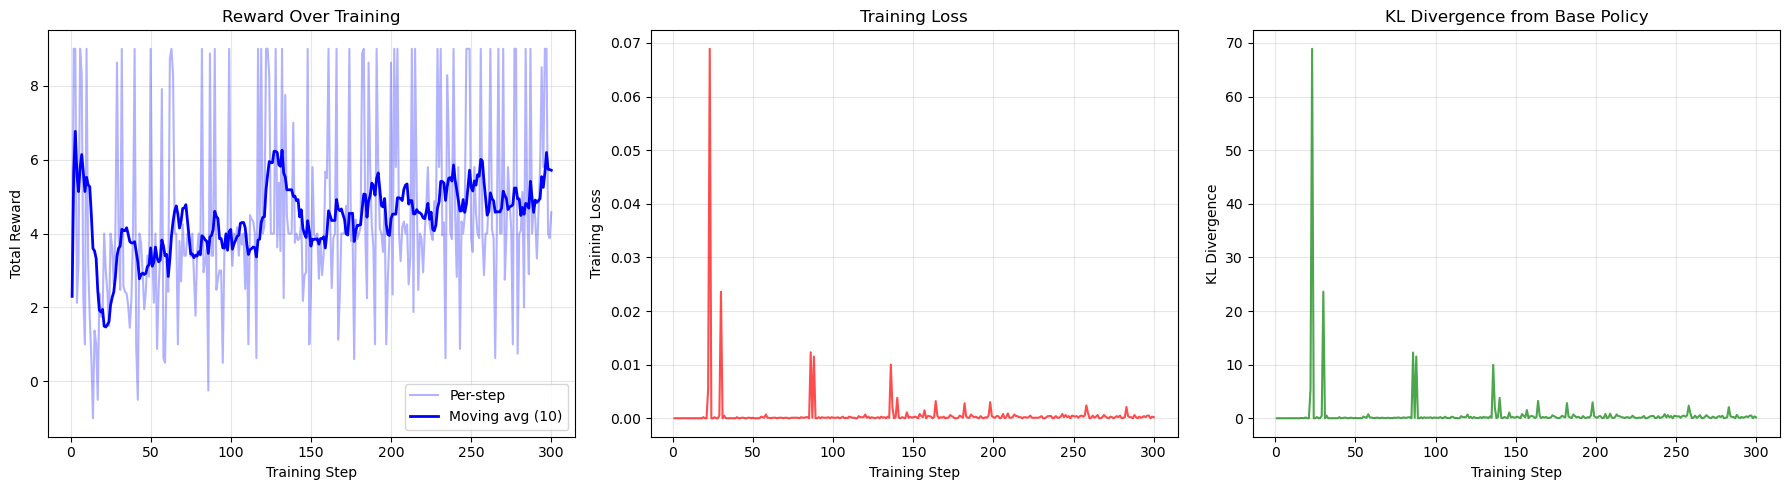

Saved to outputs/training_curves.png

FINAL RESULTS SUMMARY

Metric                             Baseline      Trained       Change
------------------------------------------------------------------
Train pass rate                      15.4%       19.2%       +3.8%
Train mean score                      0.370        0.617       +0.247
Test pass rate (gen.)                12.0%       16.0%       +4.0%
Test mean score (gen.)                0.370        0.617       +0.247

Results saved to outputs/eval_results.json


In [20]:
import matplotlib.pyplot as plt

# Extract training logs from trainer
logs = trainer.state.log_history

steps = [l["step"] for l in logs if "reward" in l]
rewards = [l["reward"] for l in logs if "reward" in l]
losses = [l["loss"] for l in logs if "loss" in l]
loss_steps = [l["step"] for l in logs if "loss" in l]
kl = [l["kl"] for l in logs if "kl" in l]
kl_steps = [l["step"] for l in logs if "kl" in l]

# Compute moving average for reward
window = 10
reward_ma = [sum(rewards[max(0,i-window):i+1]) / len(rewards[max(0,i-window):i+1]) for i in range(len(rewards))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reward curve
axes[0].plot(steps, rewards, alpha=0.3, color="blue", label="Per-step")
axes[0].plot(steps, reward_ma, color="blue", linewidth=2, label=f"Moving avg ({window})")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Total Reward")
axes[0].set_title("Reward Over Training")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(loss_steps, losses, color="red", alpha=0.7)
axes[1].set_xlabel("Training Step")
axes[1].set_ylabel("Training Loss")
axes[1].set_title("Training Loss")
axes[1].grid(True, alpha=0.3)

# KL divergence
axes[2].plot(kl_steps, kl, color="green", alpha=0.7)
axes[2].set_xlabel("Training Step")
axes[2].set_ylabel("KL Divergence")
axes[2].set_title("KL Divergence from Base Policy")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/training_curves.png")

# ============================================================
# FINAL SUMMARY TABLE
# ============================================================
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

def score_of(results):
    return sum(r["score"] for r in results) / max(len(results), 1)

def pass_rate(results):
    return sum(1 for r in results if r["passed"]) / max(len(results), 1)

print(f"\n{'Metric':<30s} {'Baseline':>12s} {'Trained':>12s} {'Change':>12s}")
print("-" * 66)
print(f"{'Train pass rate':<30s} {pass_rate(baseline_train):>11.1%} {pass_rate(trained_train):>11.1%} "
      f"{pass_rate(trained_train) - pass_rate(baseline_train):>+11.1%}")
print(f"{'Train mean score':<30s} {score_of(baseline_train):>12.3f} {score_of(trained_train):>12.3f} "
      f"{score_of(trained_train) - score_of(baseline_train):>+12.3f}")
print(f"{'Test pass rate (gen.)':<30s} {pass_rate(baseline_test):>11.1%} {pass_rate(trained_test):>11.1%} "
      f"{pass_rate(trained_test) - pass_rate(baseline_test):>+11.1%}")
print(f"{'Test mean score (gen.)':<30s} {score_of(baseline_test):>12.3f} {score_of(trained_test):>12.3f} "
      f"{score_of(trained_test) - score_of(baseline_test):>+12.3f}")

# Save all results
import os
os.makedirs("outputs", exist_ok=True)
all_results = {
    "baseline_train": baseline_train,
    "baseline_test": baseline_test,
    "trained_train": trained_train,
    "trained_test": trained_test,
}
with open("outputs/eval_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nResults saved to outputs/eval_results.json")

## Conclusion

In this tutorial, we trained an LLM to automate HR workflows using reinforcement learning. Key concepts:

1. **OpenEnv** for standardized access to enterprise RL environments
2. **Rubric-based rewards** that verify tool usage, parameter correctness, and sequencing
3. **Multi-objective rewards** (valid JSON + rubric score + efficiency)
4. **GRPO** for policy optimization without a value network
5. **LoRA** for memory-efficient fine-tuning on consumer GPUs
6. **Proper train/test split** — 70/30 stratified split to measure generalization

### Key Results

| Metric | Base Model | Trained | Change |
|--------|-----------|---------|--------|
| Train pass rate | 15.4% | 19.2% | +3.8% |
| Train mean score | 0.370 | 0.617 | +0.247 (+67%) |
| **Test pass rate** | **12.0%** | **16.0%** | **+4.0%** |
| **Test mean score** | **0.370** | **0.617** | **+0.247 (+67%)** |

### Improvement by Difficulty

| Difficulty | Baseline Score | Trained Score | Change |
|------------|---------------|---------------|--------|
| Simple | 0.23 | 0.50 | +0.27 |
| Medium | 0.72 | 0.86 | +0.14 |
| Complex | 0.26 | 0.68 | **+0.42** |
| Edge case | 0.22 | 0.25 | +0.03 |

The biggest improvement is on **complex tasks** (scores more than doubled), and the improvement **generalizes to held-out test tasks** — proving the model learned transferable HR workflow skills, not just memorization.

### Resources

- [HR Environment on HF Spaces](https://huggingface.co/spaces/devxpy/rl_hack)
- [OpenEnv Documentation](https://github.com/meta-pytorch/OpenEnv)
- [TRL GRPO Trainer](https://huggingface.co/docs/trl/main/en/grpo_trainer)
- [Unsloth RL Guide](https://docs.unsloth.ai/get-started/reinforcement-learning-rl-guide)

---

*This notebook uses [Unsloth](https://github.com/unslothai/unsloth) for memory-efficient training.*

**License:** Apache 2.0